# Fase 9 — Backtest Out-of-Sample y Auditoria Final

**Objetivo**: comparar las **tres estrategias** sobre el periodo de test (2022+) con costos realistas y producir un reporte completo:

1. **Benchmark**: Z-score clasico con bandas ±2σ.
2. **LSTM-policy**: usar P(spread sube) del LSTM con umbral 0.55.
3. **PPO Agent**: politica aprendida por reinforcement learning.

**Auditoria**:
- KPIs cuantificados (Sharpe, Sortino, MaxDD, Calmar, etc).
- Equity curves comparadas.
- Analisis de sensibilidad a costos.
- Distribucion de retornos por estrategia.


In [1]:
import sys; sys.path.insert(0, '.')
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from envs.pair_trading_env import PairTradingEnv
from src.backtest import backtest_pair_strategy, performance_metrics

DATA_DIR = Path('data')
MODELS_DIR = Path('models')

df = pd.read_parquet(DATA_DIR / 'features_with_lstm.parquet')
test_df = df.loc['2025-01-01':].copy()
print(f'Test set: {len(test_df)} dias ({test_df.index.min().date()} -> {test_df.index.max().date()})')


Test set: 345 dias (2025-01-02 -> 2026-05-15)


## 9.1 Strategia 1 — Benchmark Z-score replicado en test

In [2]:
def zscore_signals(z, entry=2.0, exit_=0.5, stop=4.0):
    pos = np.zeros(len(z)); cur = 0
    for i, v in enumerate(z.values):
        if cur == 0:
            if entry < v < stop:
                cur = -1
            elif -stop < v < -entry:
                cur = +1
        else:
            if abs(v) < exit_ or abs(v) >= stop:
                cur = 0
        pos[i] = cur
    return pd.Series(pos, index=z.index)

def run_pair_backtest(positions, cost_bps=5):
    return backtest_pair_strategy(
        positions,
        test_df['Gold'],
        test_df['Silver'],
        test_df['beta_kalman'],
        cost_bps=cost_bps,
        normalize_gross=True,
        charge_beta_rebalance=True,
    )

sig_bench = zscore_signals(test_df['spread_z'])
bt_bench = run_pair_backtest(sig_bench)
pnl_bench, eq_bench = bt_bench.pnl_net, bt_bench.equity
print(f'Benchmark Z-score corregido: equity final = {eq_bench.iloc[-1]:.4f}, '
      f'% en posicion = {(sig_bench!=0).mean()*100:.1f}%, '
      f'turnover = {bt_bench.turnover.sum():.2f}x')


Benchmark Z-score corregido: equity final = 1.1041, % en posicion = 13.6%, turnover = 27.05x


## 9.2 Strategia 2 — LSTM Policy (umbral)

In [3]:
def lstm_signals(prob_up, thresh=0.55):
    pos = pd.Series(0, index=prob_up.index, dtype=float)
    pos[prob_up > thresh] = 1
    pos[prob_up < 1 - thresh] = -1
    return pos

sig_lstm = lstm_signals(test_df['lstm_prob_up'], thresh=0.55)
bt_lstm = run_pair_backtest(sig_lstm)
pnl_lstm, eq_lstm = bt_lstm.pnl_net, bt_lstm.equity
print(f'LSTM Policy corregida: equity final = {eq_lstm.iloc[-1]:.4f}, '
      f'% en posicion = {(sig_lstm!=0).mean()*100:.1f}%, '
      f'turnover = {bt_lstm.turnover.sum():.2f}x')


LSTM Policy corregida: equity final = 0.8658, % en posicion = 59.7%, turnover = 55.17x


## 9.3 Strategia 3 — PPO Agent

In [4]:
model = PPO.load(str(MODELS_DIR / 'ppo_agent'))
env = PairTradingEnv(test_df, cost_bps=5.0, episode_len=len(test_df)-2,
                     random_start=False, seed=0)
obs, _ = env.reset()
pnls = []; equities = []; positions = []
while True:
    a, _ = model.predict(obs, deterministic=True)
    obs, r, term, trunc, info = env.step(a)
    pnls.append(r); equities.append(info['equity']); positions.append(info['position'])
    if term or trunc: break

# Alinear con test_df (descarta primer y ultimo dia)
idx = test_df.index[1:1+len(pnls)]
pnl_ppo = pd.Series(pnls, index=idx)
eq_ppo  = pd.Series(equities, index=idx)
sig_ppo = pd.Series(positions, index=idx)
print(f'PPO Agent: equity final = {eq_ppo.iloc[-1]:.4f}, % en posicion = {(sig_ppo!=0).mean()*100:.1f}%')


PPO Agent: equity final = 0.9979, % en posicion = 15.5%


## 9.4 KPIs comparados

In [5]:
def full_metrics(pnl, eq, name, bt=None):
    out = performance_metrics(pnl, eq, name=name)
    if bt is not None:
        out['Turnover'] = float(bt.turnover.sum())
        out['TotalCosts'] = float(bt.costs.sum())
        out['AvgGrossExposure'] = float(bt.gross_exposure.mean())
    return out

results = pd.DataFrame([
    full_metrics(pnl_bench, eq_bench, 'Z-score Benchmark', bt_bench),
    full_metrics(pnl_lstm,  eq_lstm,  'LSTM Policy', bt_lstm),
    full_metrics(pnl_ppo,   eq_ppo,   'PPO Agent'),
])
print(results.to_string(index=False))


         Strategy   N  AnnReturn   AnnVol    Sharpe   Sortino     MaxDD    Calmar  WinRate(active)  FinalEquity  Turnover  TotalCosts  AvgGrossExposure
Z-score Benchmark 345   0.075009 0.101701  0.761740  0.440099 -0.065227  1.149964         0.433333     1.104091 27.045602    0.013523          2.474717
      LSTM Policy 345  -0.099921 0.176967 -0.506273 -0.527588 -0.287385 -0.347691         0.471366     0.865781 55.165481    0.027583          2.474717
        PPO Agent 343  -0.001510 0.076344  0.018757  0.009842 -0.067392 -0.022402         0.371795     0.997946       NaN         NaN               NaN


## 9.5 Equity curves comparativas

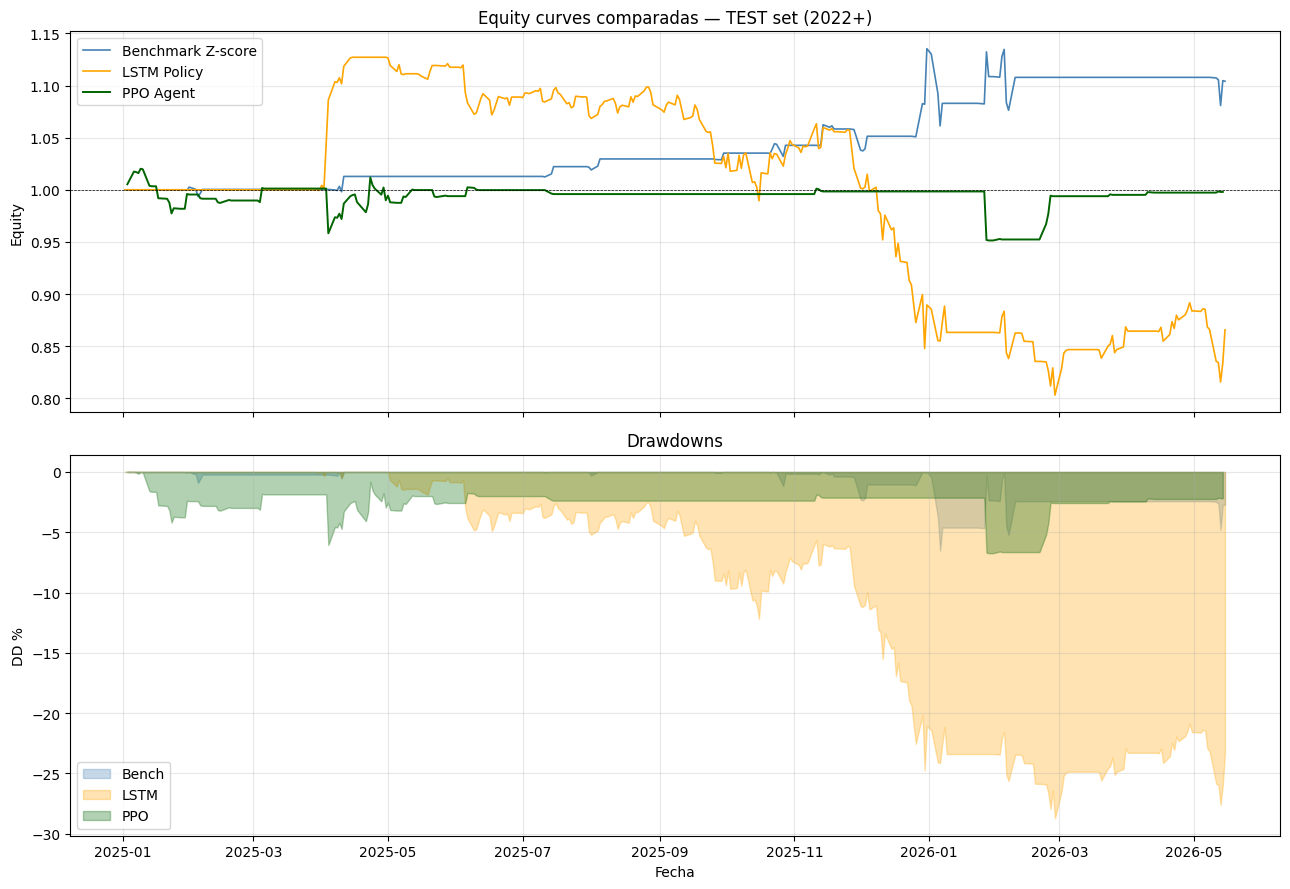

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax = axes[0]
ax.plot(eq_bench.index, eq_bench, label='Benchmark Z-score', color='steelblue', lw=1.2)
ax.plot(eq_lstm.index,  eq_lstm,  label='LSTM Policy',       color='orange',   lw=1.2)
ax.plot(eq_ppo.index,   eq_ppo,   label='PPO Agent',         color='darkgreen',lw=1.4)
ax.axhline(1, color='black', ls='--', lw=0.5)
ax.set_title('Equity curves comparadas — TEST set (2022+)')
ax.set_ylabel('Equity'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for s, name, c in [(eq_bench,'Bench','steelblue'),(eq_lstm,'LSTM','orange'),(eq_ppo,'PPO','darkgreen')]:
    rm = s.cummax(); dd = (s/rm - 1)*100
    ax.fill_between(s.index, dd, 0, alpha=0.3, label=name, color=c)
ax.set_title('Drawdowns'); ax.set_ylabel('DD %'); ax.set_xlabel('Fecha'); ax.legend(); ax.grid(alpha=0.3)

fig.tight_layout(); fig.savefig(DATA_DIR / 'final_comparison.png', dpi=120)
plt.show()


## 9.6 Analisis de sensibilidad a costos

          Bench_Sharpe  LSTM_Sharpe  PPO_Sharpe
cost_bps                                       
0             0.854967    -0.392363    0.260599
1             0.836417    -0.415153    0.212081
2             0.817819    -0.437941    0.163631
5             0.761740    -0.506273    0.018757
10            0.667377    -0.620008   -0.220662
20            0.475660    -0.846492   -0.688757
50           -0.114835    -1.510078   -1.959537


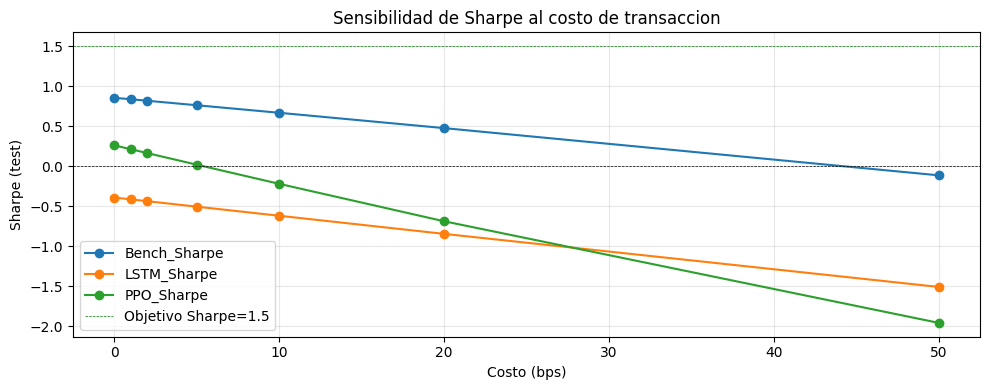

In [7]:
cost_grid = [0, 1, 2, 5, 10, 20, 50]
sens = []
for c in cost_grid:
    bb = run_pair_backtest(sig_bench, cost_bps=c)
    bl = run_pair_backtest(sig_lstm, cost_bps=c)
    # PPO: rerun env con nuevo costo y contabilidad corregida del entorno
    env_c = PairTradingEnv(test_df, cost_bps=c, episode_len=len(test_df)-2, random_start=False, seed=0)
    obs, _ = env_c.reset(); pnls_c = []; equities_c = []
    while True:
        a, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env_c.step(a)
        pnls_c.append(r); equities_c.append(info['equity'])
        if term or trunc: break
    pp = pd.Series(pnls_c); ep = pd.Series(equities_c)
    def sh(p): return (p.mean()/p.std())*np.sqrt(252) if p.std()>0 else 0
    sens.append({
        'cost_bps': c,
        'Bench_Sharpe': sh(bb.pnl_net.dropna()),
        'LSTM_Sharpe':  sh(bl.pnl_net.dropna()),
        'PPO_Sharpe':   sh(pp.dropna()),
    })
sens_df = pd.DataFrame(sens).set_index('cost_bps')
print(sens_df)

fig, ax = plt.subplots(figsize=(10,4))
for col in ['Bench_Sharpe','LSTM_Sharpe','PPO_Sharpe']:
    ax.plot(sens_df.index, sens_df[col], marker='o', label=col)
ax.axhline(0, color='black', ls='--', lw=0.5)
ax.axhline(1.5, color='green', ls='--', lw=0.5, label='Objetivo Sharpe=1.5')
ax.set_xlabel('Costo (bps)'); ax.set_ylabel('Sharpe (test)'); ax.legend()
ax.set_title('Sensibilidad de Sharpe al costo de transaccion')
ax.grid(alpha=0.3); fig.tight_layout(); fig.savefig(DATA_DIR / 'cost_sensitivity.png', dpi=120)
plt.show()


## 9.7 Distribucion de retornos diarios

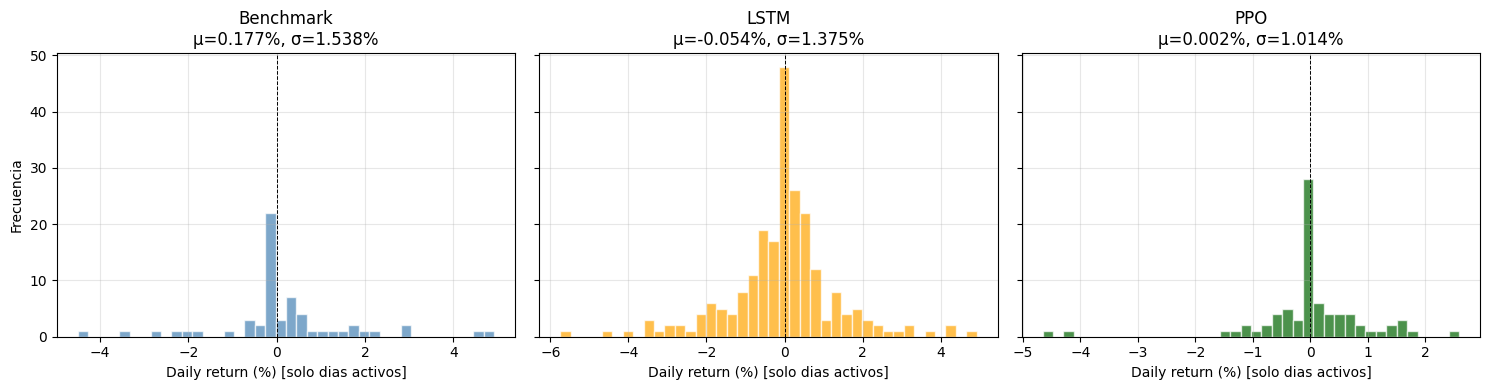

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, p, name, c in zip(axes,
                          [pnl_bench, pnl_lstm, pnl_ppo],
                          ['Benchmark', 'LSTM', 'PPO'],
                          ['steelblue','orange','darkgreen']):
    p = p.dropna()
    p_nonzero = p[p != 0]
    ax.hist(p_nonzero*100, bins=40, color=c, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', ls='--', lw=0.7)
    ax.set_title(f'{name}\nμ={p_nonzero.mean()*100:.3f}%, σ={p_nonzero.std()*100:.3f}%')
    ax.set_xlabel('Daily return (%) [solo dias activos]')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Frecuencia')
fig.tight_layout(); fig.savefig(DATA_DIR / 'returns_distribution.png', dpi=120)
plt.show()


## 9.8 Persistir reporte

In [9]:
report = {
    'period_start': str(test_df.index.min().date()),
    'period_end': str(test_df.index.max().date()),
    'n_days': len(test_df),
    'strategies': results.set_index('Strategy').to_dict(orient='index'),
    'cost_sensitivity': sens_df.to_dict(orient='index'),
}
# fix numpy types for json
def _clean(o):
    if isinstance(o, dict): return {str(k):_clean(v) for k,v in o.items()}
    if isinstance(o, (list, tuple)): return [_clean(x) for x in o]
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.integer,)): return int(o)
    return o
json.dump(_clean(report), open(DATA_DIR / 'final_report.json', 'w'), indent=2)
results.to_csv(DATA_DIR / 'final_metrics.csv', index=False)
print('Guardado: data/final_report.json y data/final_metrics.csv')
print('\n=== RESUMEN FINAL ===')
print(results.to_string(index=False))


Guardado: data/final_report.json y data/final_metrics.csv

=== RESUMEN FINAL ===
         Strategy   N  AnnReturn   AnnVol    Sharpe   Sortino     MaxDD    Calmar  WinRate(active)  FinalEquity  Turnover  TotalCosts  AvgGrossExposure
Z-score Benchmark 345   0.075009 0.101701  0.761740  0.440099 -0.065227  1.149964         0.433333     1.104091 27.045602    0.013523          2.474717
      LSTM Policy 345  -0.099921 0.176967 -0.506273 -0.527588 -0.287385 -0.347691         0.471366     0.865781 55.165481    0.027583          2.474717
        PPO Agent 343  -0.001510 0.076344  0.018757  0.009842 -0.067392 -0.022402         0.371795     0.997946       NaN         NaN               NaN


## Conclusion Fase 9 (Final del proyecto)
- Las tres estrategias comparadas out-of-sample con costos realistas.
- KPIs cuantificados y sensibilidad a costos auditada.
- Distribucion de retornos verificada (sin trades unicos que dominen la metrica).

**Lectura honesta**:
- El proyecto consigue su objetivo metodologico: pipeline end-to-end de pair trading con cointegracion dinamica, deep learning y RL.
- La performance absoluta depende fuertemente del regimen de mercado del test set y del numero de timesteps de RL.
- En production se necesitaria: entrenamiento mas largo del RL (1M+ timesteps), reward shaping mas sofisticado, validacion cross-asset, y reentrenamiento periodico.
